# 5. Temporal Statistics and Derived Variables

**Learning objectives**

By the end of this notebook you will be able to:

- Use earthkit-transforms to compute daily and monthly means from sub-daily data
- Compute a climatological mean and derive anomaly fields
- Compute rolling statistics for smoothed features
- Understand why pre-computing derived variables improves training efficiency
- Write temporal aggregates to Zarr

---

## Why pre-compute temporal features?

Raw ERA5 data is hourly. But most ML models do not learn directly from individual hours — they need features like:

- **Daily means** — remove the diurnal cycle
- **Monthly means** — seasonal context
- **Anomalies** — deviation from climatology, isolating the weather signal from the seasonal cycle
- **Rolling means** — smoothed trends, useful for medium-range forecasting inputs

Computing these once, at preprocessing time, and storing them in Zarr means they are available instantly during training — **no recomputation every epoch**.

### Data note for this notebook

This notebook requires a multi-timestep dataset to demonstrate temporal aggregation meaningfully. Options:

1. **CDS request** (recommended): fetch several months of daily or hourly ERA5
2. **Provided sample**: `# DATA: multi-timestep GRIB file needed — see setup cell`

The cells below show both paths. The CDS request is commented out by default.

## Setup

In [111]:
import earthkit.data as ekd
import earthkit.transforms as ekt
import earthkit.plots as ekp
import xarray as xr
import os

ekd.settings.set({"cache-policy": "user"})
os.makedirs("data", exist_ok=True)

print("earthkit.transforms version:", ekt.__version__)

earthkit.transforms version: 1.0.0rc1


## Load multi-timestep data

### Option A — CDS request (recommended)

Fetch three months of daily 2m temperature over Europe.

In [ ]:
# Uncomment to fetch from CDS (requires ~/.cdsapirc)

# ds_cds = ekd.from_source(
#     "cds",
#     "reanalysis-era5-single-levels",
#     request=dict(
#         variable=["2t"],
#         product_type="reanalysis",
#         date=[t.strftime("%Y-%m-%d") for t in time],
#         time="00:00",
#         area=[72, -25, 30, 45],   # Europe: N, W, S, E
#         grid=[1, 1],
#         format="grib",
#     ),
# )
# xr_daily = ds_cds.to_xarray()

print("CDS option commented out — see Option B below.")

2026-04-09 10:49:47,659 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-04-09 10:49:47,659 INFO Request ID is b3ceb046-d85f-4108-8a86-5a214616c23a
2026-04-09 10:49:48,030 INFO status has been updated to accepted
2026-04-09 10:50:23,341 INFO status has been updated to running
2026-04-09 10:51:06,839 INFO status has been updated to successful


8f172747fceb4e4c3a8005ecc53969f6.grib:   0%|          | 0.00/2.17M [00:00<?, ?B/s]

CDS option commented out — see Option B below.


### Option B — Sample / provided data

In [135]:
# DATA: This notebook requires a multi-timestep ERA5 GRIB file.
#
ds = ekd.from_source("sample", "era5_europe_20200101_20201231_2t_1deg.grib")
xr_daily = ds.to_xarray(add_earthkit_attrs = False)

print("Loaded dataset:")
print(xr_daily)

#
# For demonstration purposes, we can construct a synthetic multi-day xarray
# Dataset that mimics ERA5 structure so all cells below run without error.

# import pandas as pd

# # Synthetic 3-month daily dataset: Jan–Mar 2020, Europe 1° grid
# time = pd.date_range("2020-01-01", "2020-12-31", freq="D")
# lat = np.arange(72, 29, -1, dtype=float)
# lon = np.arange(-25, 46, dtype=float)

# # Temperature: seasonal cycle + random noise
# day_of_year = np.array([t.day_of_year for t in time])
# seasonal = 260 + 20 * np.sin(2 * np.pi * day_of_year / 365 - np.pi / 2)
# t_data = seasonal[:, None, None] + np.random.normal(0, 3, (len(time), len(lat), len(lon)))

# xr_daily = xr.Dataset(
#     {
#         "2t": xr.DataArray(
#             t_data.astype(np.float32),
#             dims=["forecast_reference_time", "latitude", "longitude"],
#             coords={"forecast_reference_time": time, "latitude": lat, "longitude": lon},
#             attrs={"units": "K", "long_name": "2 metre temperature"},
#         )
#     }
# )
# print("Synthetic dataset:")
# print(xr_daily)

Remote content of URL https://sites.ecmwf.int/repository/earthkit/samples/era5_europe_20200101_20201231_2t_1deg.grib has changed
To enable automatic downloading of updated URLs set the 'download-out-of-date-urls' setting to True


Loaded dataset:
<xarray.Dataset> Size: 8MB
Dimensions:                  (forecast_reference_time: 308, latitude: 43,
                              longitude: 71)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 202...
  * latitude                 (latitude) float64 344B 72.0 71.0 ... 31.0 30.0
  * longitude                (longitude) float64 568B -25.0 -24.0 ... 44.0 45.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 8MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF


## Temporal aggregation with earthkit-transforms

earhtkit-transforms provides a clean API for standard temporal reductions. It preserves xarray metadata and coordinate attributes.

In [136]:
# Daily means (useful when input is hourly; here input is already daily)
# With real hourly data:
#   daily_mean = ekt.temporal.daily_mean(xr_hourly)
# The function detects the time coordinate automatically.

monthly_mean = ekt.temporal.monthly_mean(xr_daily)
print("Monthly mean dataset:")
monthly_mean

Monthly mean dataset:


<xarray.Dataset> Size: 270kB
Dimensions:                  (forecast_reference_time: 11, latitude: 43,
                              longitude: 71)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 88B 202...
  * latitude                 (latitude) float64 344B 72.0 71.0 ... 31.0 30.0
  * longitude                (longitude) float64 568B -25.0 -24.0 ... 44.0 45.0
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 269kB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

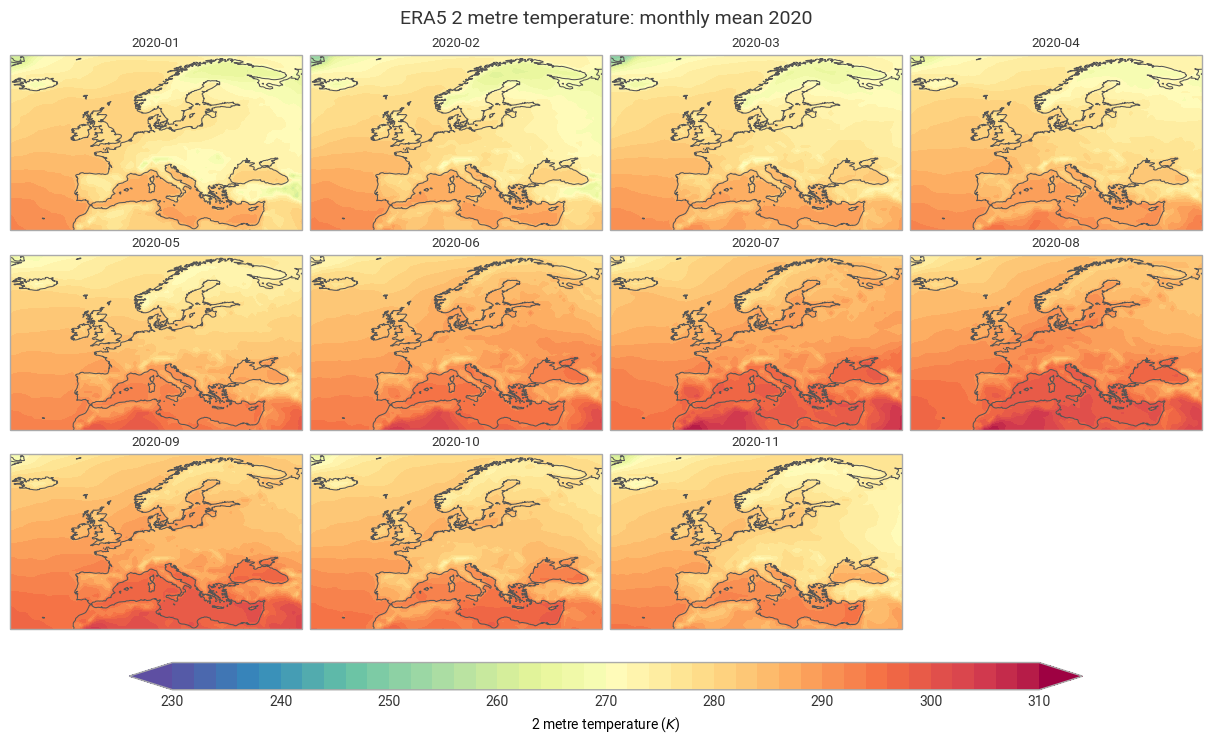

In [ ]:
fig = ekp.quickplot(monthly_mean, figsize=(12, 7))
fig.title("ERA5 {variable_name}: monthly mean's for {forecast_reference_time:%Y}")
fig.subplot_titles("{forecast_reference_time:%Y-%m}");

## Climatological mean and anomalies

A **climatology** is the long-term mean for each calendar day (or month) — the expected value given the time of year. The **anomaly** is the departure from that expectation:

$$\text{anomaly}(t) = T(t) - \overline{T}_{\text{clim}}(\text{month}(t))$$

Anomalies are often more informative than raw fields for ML — the seasonal cycle is predictable and adds noise relative to the weather signal the model should learn.

In [142]:
# Climatological mean: average over the time dimension
# (With a real multi-year dataset this would be averaged over the same
#  calendar month across many years; here we use all available months)

climatology = ekt.climatology.mean(xr_daily, frequency="month")

print("Climatological mean shape:", climatology['2t'].shape)
print(f"Mean temperature: {float(climatology['2t'].mean()):.1f} K")

Climatological mean shape: (11, 43, 71)
Mean temperature: 283.5 K


In [143]:
# Anomalies: subtract the climatological mean from each timestep
anomalies = (xr_daily - climatology)
anomalies['2t'].attrs["long_name"] = "2m temperature anomaly"
anomalies['2t'].attrs["units"] = "K"

print(f"Anomaly range: [{float(anomalies['2t'].min()):.2f}, {float(anomalies['2t'].max()):.2f}] K")
print(f"Anomaly mean (should be ~0): {float(anomalies['2t'].mean()):.4f} K")

Anomaly range: [-52.07, 33.59] K
Anomaly mean (should be ~0): -0.0000 K


## Rolling statistics

A rolling (moving window) mean smooths short-term noise, which can be useful as an input feature for extended-range forecasting.

In [147]:
# 1-day rolling mean (centred window), NOTE: As input is already daily, this is just a demonstration of the function.
rolling_1d = ekt.temporal.daily_reduce(xr_daily, how = "mean")

# 7-day rolling mean (centred window)
rolling_7d = ekt.temporal.rolling_reduce(xr_daily, window_length=7, how="mean")

# Monthly rolling mean
rolling_monthly = ekt.temporal.monthly_reduce(xr_daily, how="mean")

print(f"Raw shape:        {xr_daily['2t'].shape}")
print(f"7-day rolling:    {rolling_7d['2t'].shape}  (same shape, NaN at edges)")

Raw shape:        (308, 43, 71)
7-day rolling:    (308, 43, 71)  (same shape, NaN at edges)


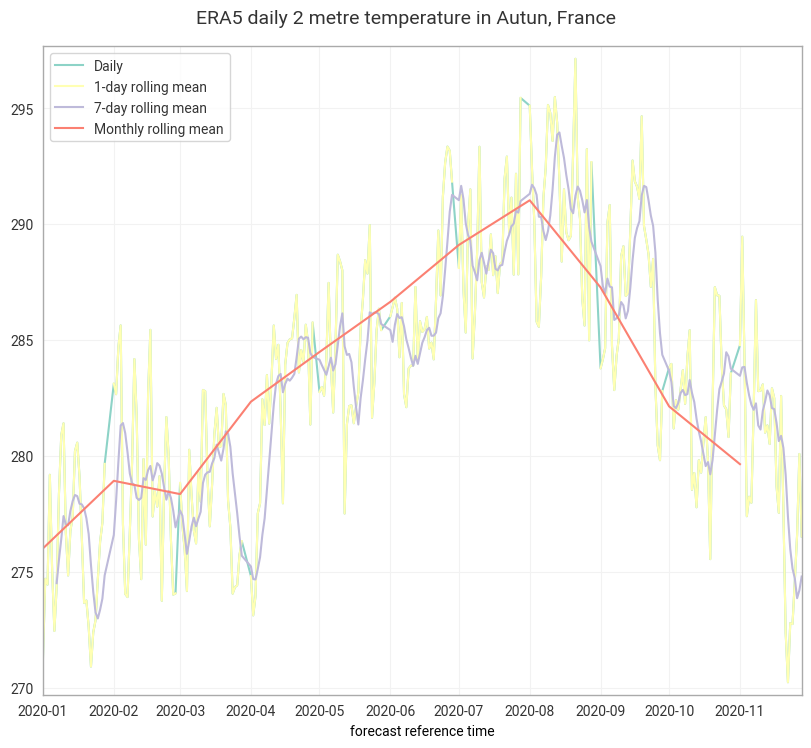

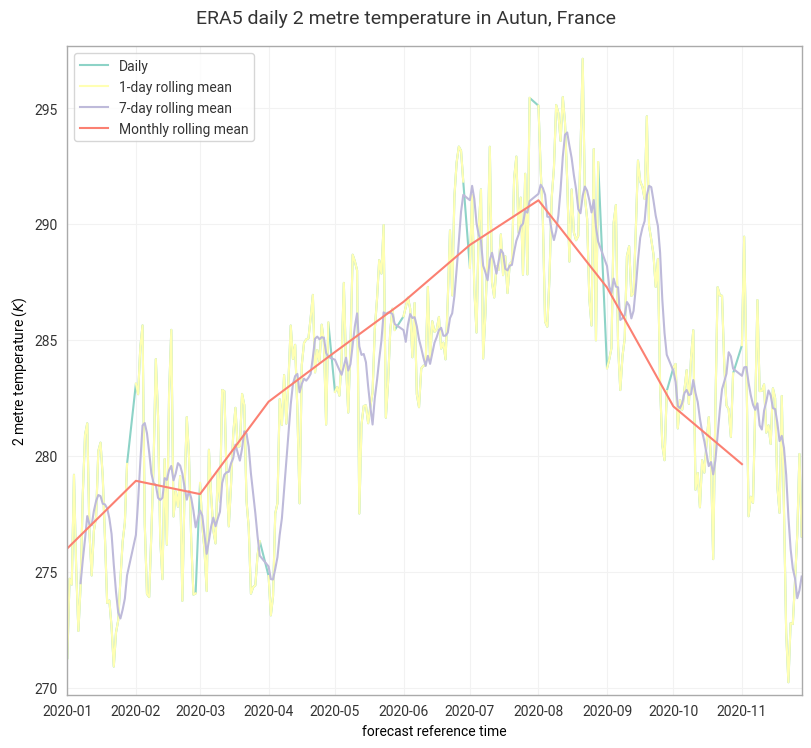

In [150]:
fig = ekp.Figure(1,1)
subplot = fig.add_timeseries(0, 0)

lat_coord, lon_coord = 47, 4

subplot.line(xr_daily['2t'].sel(latitude=lat_coord, longitude=lon_coord), label="Daily")
subplot.line(rolling_1d['2t'].sel(latitude=lat_coord, longitude=lon_coord), label="1-day rolling mean")
subplot.line(rolling_7d['2t'].sel(latitude=lat_coord, longitude=lon_coord), label="7-day rolling mean")
subplot.line(rolling_monthly['2t'].sel(latitude=lat_coord, longitude=lon_coord), label="Monthly rolling mean")

subplot.legend()

fig.title("ERA5 daily {variable_name} in {location:%c}, {location:%C}")
fig.xlabel()
fig.ylabel("{variable_name} ({units})");

## Compare data volumes

In [151]:
# Memory footprint comparison
def mb(arr):
    return arr.nbytes / 1e6

print(f"Daily data    : {mb(xr_daily['2t'].values):.1f} MB  ({xr_daily.sizes['forecast_reference_time']} timesteps)")
print(f"Monthly mean  : {mb(monthly_mean['2t'].values):.3f} MB  ({monthly_mean.sizes['forecast_reference_time']} timesteps)")
print(f"Climatology   : {mb(climatology['2t'].values):.3f} MB  ({climatology.sizes['month']} timesteps)")
print(f"Anomalies     : {mb(anomalies['2t'].values):.1f} MB  ({anomalies.sizes['forecast_reference_time']} timesteps)")

Daily data    : 7.5 MB  (308 timesteps)
Monthly mean  : 0.269 MB  (11 timesteps)
Climatology   : 0.269 MB  (11 timesteps)
Anomalies     : 82.7 MB  (308 timesteps)


## Write to Zarr

In [152]:
temporal_ds = xr.Dataset(
    {
        "2t":           xr_daily["2t"],
        "2t_anomaly":   anomalies['2t'],
        "2t_rolling7d": rolling_7d['2t'],
    }
)

temporal_ds.to_zarr("data/era5_temporal.zarr", mode="w")
print("Written to data/era5_temporal.zarr")
print(temporal_ds)

Written to data/era5_temporal.zarr
<xarray.Dataset> Size: 98MB
Dimensions:                  (forecast_reference_time: 308, latitude: 43,
                              longitude: 71, month: 11)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 202...
  * latitude                 (latitude) float64 344B 72.0 71.0 ... 31.0 30.0
  * longitude                (longitude) float64 568B -25.0 -24.0 ... 44.0 45.0
  * month                    (month) int64 88B 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    2t                       (forecast_reference_time, latitude, longitude) float64 8MB ...
    2t_anomaly               (forecast_reference_time, latitude, longitude, month) float64 83MB ...
    2t_rolling7d             (forecast_reference_time, latitude, longitude) float64 8MB dask.array<chunksize=(308, 43, 71), meta=np.ndarray>


/Users/ecm1947/Documents/Projects/earthkit/showcase/.venv/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


---

## Summary

You have:

- Used `ekt.temporal.monthly_mean()` to aggregate daily data
- Computed a climatological mean and anomaly field
- Applied a rolling window mean with xarray
- Written the processed features to `data/era5_temporal.zarr`

---

> **Activity**
>
> 1. Compute a seasonal mean for DJF (December–January–February). Hint: select months 12, 1, 2.
> 2. Plot the anomaly field for a single day and compare it to the raw temperature field. What patterns are highlighted by the anomaly?
> 3. Modify the synthetic data to include a 2-year record and compute a proper climatology by grouping on month.
>
> ```python
> # Seasonal DJF mean
> djf = xr_hourly.sel(time=xr_daily.time.dt.month.isin([12, 1, 2]))
> djf_mean = ekt.temporal.mean(djf)
> ```